In [3]:
import pandas as pd
from sklearn.svm import SVC
df = pd.read_csv("student_svm_data.csv")

X = df[[
    "StudyHours",
    "Attendance",
    "PreviousScore",
    "PracticeTests"
]]

y = df["Passed"]

model = SVC()

model.fit(X, y)

accuracy = model.score(X, y)

print("Accuracy:", accuracy)

Accuracy: 0.71


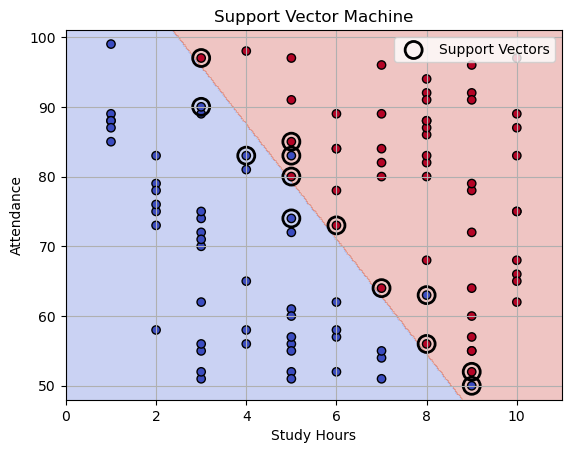

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC

df = pd.read_csv("student_svm_data.csv")

X = df[[
    "StudyHours",
    "Attendance"
]].values

y = df["Passed"]

# Train SVM
model = SVC(kernel="linear")
model.fit(X, y)

# Create mesh
x_min = X[:, 0].min() - 1
x_max = X[:, 0].max() + 1

y_min = X[:, 1].min() - 2
y_max = X[:, 1].max() + 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

# Training data
plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="coolwarm",
    edgecolors="black"
)

# Support vectors
plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=150,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Support Vector Machine")
plt.legend()
plt.grid(True)

plt.show()